In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Limit the columns to save the RAM for loading-able 1Gb file
# use_cols = [
#     'client_id',
#     'amount',
#     'merchant_id',
#     'use_chip',
#     'merchant_state'
# ]


# transactionDf = pd.read_csv(
#     'transactions_data_25pc.csv',
#     usecols=use_cols
# )

# transactionDf.head(1000)


transactionDf = pd.read_csv('transactions_data_25pc.csv')

merchant_df = pd.read_csv('mcc_codes.csv')
merchant_ids = merchant_df['mcc_code']

user_columns = ['id', 'retirement_age', 'birth_year', 'gender', 'yearly_income', 'total_debt','credit_score', 'per_capita_income']
userDf = pd.read_csv('users_data.csv', usecols=user_columns)
clientIds = userDf['id']

transactionDf.head()


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,11978328,2012-11-23 16:03:00,619,3348,$263.43,Swipe Transaction,54850,Austin,MN,55912.0,4814,NaN
1,11363233,2012-07-07 13:57:00,456,4576,$38.26,Swipe Transaction,68135,Cape Coral,FL,33909.0,5411,NaN
2,8117710,2010-06-10 16:59:00,209,4676,$52.57,Swipe Transaction,81833,El Paso,TX,79928.0,5912,NaN
3,12606562,2013-04-13 12:08:00,1605,1133,$40.00,Swipe Transaction,27092,Amelia,OH,45102.0,4829,NaN
4,12628171,2013-04-18 10:00:00,144,5247,$4.58,Swipe Transaction,44578,Arkadelphia,AR,71923.0,5812,NaN


In [93]:
# Convert transaction.amount to number
transactionDf['amount'] = transactionDf['amount'].str.replace(r'[\$,]', '', regex=True).astype('float32')

# convert users_data.yearly_income and users_data.total_dept to number
userDf['yearly_income'] = userDf['yearly_income'].astype(str).str.replace(r'[\$,]', '', regex=True).astype('float32')
userDf['total_debt'] = userDf['total_debt'].astype(str).str.replace(r'[\$,]', '', regex=True).astype('float32')

# common data collections
totalSpendingByClient = transactionDf[transactionDf['client_id'].isin(list(clientIds))].groupby('client_id')['amount'].sum()

# Client_id = 0 looks so wrong
client_id_0_Df = transactionDf[transactionDf['client_id'] == 0]
print(len(client_id_0_Df)) #3205
transactionDf.sort_values(by='client_id', ascending=True).head(1000)

3205


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
877896,16806672,2015-10-14 19:33:00,0,1271,8.080000,Chip Transaction,55060,Scarborough,ME,4074.0,5812,NaN
1891261,18818876,2016-12-18 14:02:00,0,1271,28.580000,Online Transaction,16798,ONLINE,NaN,NaN,4121,NaN
2235606,16927527,2015-11-09 19:31:00,0,1271,8.300000,Chip Transaction,13153,Scarborough,ME,4074.0,5812,NaN
256912,19887064,2017-08-01 22:24:00,0,4639,46.630001,Chip Transaction,32164,Scarborough,ME,4074.0,5813,NaN
2260412,16617880,2015-09-04 14:36:00,0,4639,74.330002,Swipe Transaction,39991,Lincoln Park,MI,48146.0,3771,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1673309,14757005,2014-07-29 14:27:00,0,4639,14.280000,Swipe Transaction,78516,Detroit,MI,48227.0,4121,NaN
1802344,10125950,2011-09-28 12:49:00,0,1271,64.610001,Swipe Transaction,43293,Scarborough,ME,4074.0,5499,NaN
2500939,23450554,2019-08-26 16:05:00,0,1271,127.309998,Online Transaction,84682,ONLINE,NaN,NaN,4900,NaN
3205433,9762390,2011-07-06 14:23:00,0,1271,22.790001,Online Transaction,16798,ONLINE,NaN,NaN,4121,NaN


<class 'pandas.core.series.Series'>


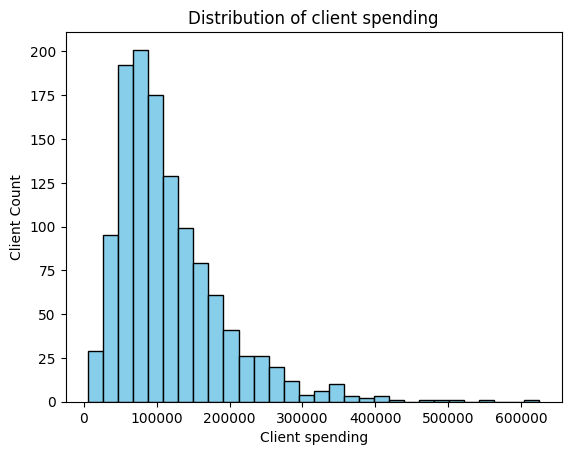

In [94]:
# *** 1. Distribution of client spending
clientTotalSpending = transactionDf[transactionDf['client_id'].isin(list(clientIds))].groupby('client_id')['amount'].sum()
print(type(clientTotalSpending))
clientTotalSpending.head()

plt.Figure(figsize=(8, 6))

plt.hist(clientTotalSpending, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of client spending")
plt.xlabel("Client spending")
plt.ylabel("Client Count")
plt.show()


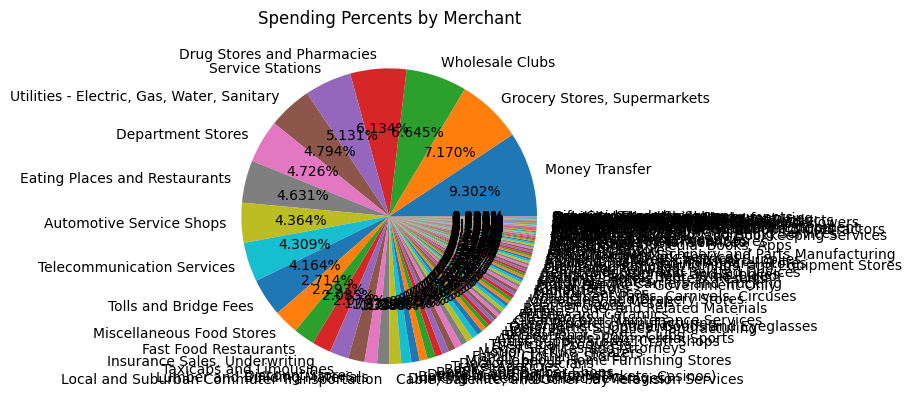

In [ ]:

#*** 2. Spending by Merchant (by State, by City?)

# filter all transactions which have merchant_id in mcc_codes table
# group by merchant_id
# sum by merchant_id
merchantTotalSpending = transactionDf[transactionDf['mcc'].isin(list(merchant_ids))].groupby('mcc')['amount'].sum()

merchantTotalSpendingDf = merchantTotalSpending.to_frame()

merchantTotalSpendingDf.head()

# Merge with mcc_codes table to get merchant name (merchant_category)
merchantTotalSpendingDf = (merchantTotalSpendingDf
                            .merge(merchant_df, left_on='mcc', right_on = 'mcc_code',  how='left')
                            .sort_values(by='amount', ascending=False))

# Get top 10 highest spending on merchant
# top10HighestMerchantTotalSpendingDf = merchantTotalSpendingDf.sort_values(by='amount', ascending=False)
# print(type(top10HighestMerchantTotalSpendingDf), len(top10HighestMerchantTotalSpendingDf))

plt.Figure(figsize=(10, 6))
plt.title('Spending Percents by Merchant')
# plt.bar(merchantTotalSpendingDf['merchant_category'], merchantTotalSpendingDf['amount'], color='blue')
# plt.pie(merchantTotalSpendingDf['amount'], labels=merchantTotalSpendingDf['merchant_category'], autopct='%1.1f%%')
# plt.xlabel('Merchant Name')
# plt.ylabel('Amount')
plt.pie(merchantTotalSpendingDf['amount'], labels=merchantTotalSpendingDf['merchant_category'], autopct='%1.3f%%')
plt.show()

In [ ]:
#*** 3. Transaction Count by Merchant
transactionMerchantGroupingDf = transactionDf[transactionDf['mcc'].isin(list(merchant_ids))].groupby('mcc')
transactionMerchantGroupingDf = transactionMerchantGroupingDf['id'].count().reset_index(name='total_transaction_count')
transactionMerchantGroupingDf = transactionMerchantGroupingDf.merge(merchant_df, left_on='mcc', right_on='mcc_code', how='left').sort_values('total_transaction_count', ascending=False)
print(type(transactionMerchantGroupingDf))

plt.figure(figsize=(8,6))
plt.pie(transactionMerchantGroupingDf['total_transaction_count'], labels=transactionMerchantGroupingDf['merchant_category'], autopct='%1.3f%%')
plt.show()

<class 'pandas.core.frame.DataFrame'>


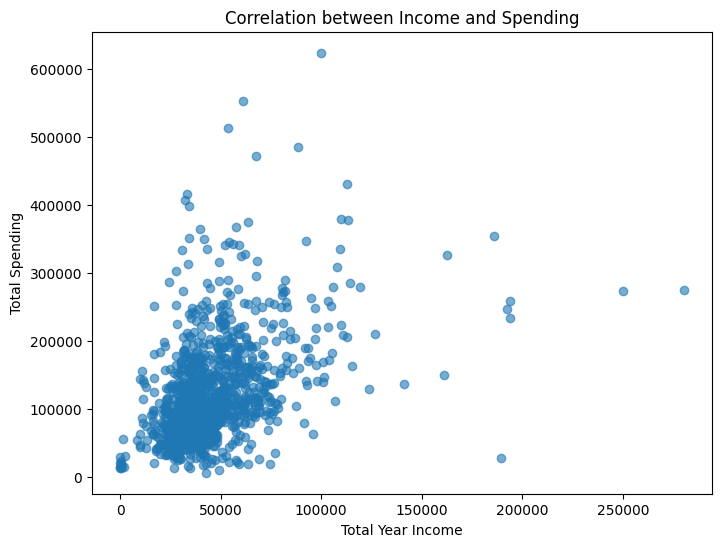

In [ ]:
# *** 4. Correlation between Income and Spending
totalSpendingByClientDf = totalSpendingByClient.to_frame()
print(type(totalSpendingByClientDf))

totalSpendingByClientDf = totalSpendingByClientDf.merge(
    userDf,
    left_on='client_id',
    right_on='id',
    how='left'
)

plt.figure(figsize=(8,6))
plt.title('Correlation between Income and Spending')
plt.scatter(totalSpendingByClientDf['yearly_income'], totalSpendingByClientDf['amount'], alpha=0.6)
plt.xlabel('Total Year Income')
plt.ylabel('Total Spending')
plt.show()
# => no correlation between income and spending but we can see the convergence of spending

In [ ]:
# *** 5. Correlation between Client's Per Capita Income and Spending
totalSpendingByClientPerCapitaIncomeDf = totalSpendingByClient.to_frame()
print(type(totalSpendingByClientPerCapitaIncomeDf))

totalSpendingByClientPerCapitaIncomeDf = totalSpendingByClientPerCapitaIncomeDf.merge(
    userDf,
    left_on='client_id',
    right_on='id',
    how='left'
)

plt.figure(figsize=(8,6))
plt.title('Correlation between Client Per Capita Income and Spending')
plt.scatter(totalSpendingByClientPerCapitaIncomeDf['per_capita_income'], totalSpendingByClientPerCapitaIncomeDf['amount'], alpha=0.6)
plt.xlabel('Total Year Income')
plt.ylabel('Total Spending')
plt.show()
# => no correlation between income and spending but we can see the convergence of spending

C:\Users\Ryan\AppData\Local\Temp\ipykernel_9228\2238508108.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  userAgeDf['age'] = userAgeDf['birth_year'].apply(lambda birthYear: datetime.now().year - birthYear)
C:\Users\Ryan\AppData\Local\Temp\ipykernel_9228\2238508108.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  userAgeDf['age_range'] = userAgeDf['birth_year'].apply(caculateAgeRange)


<class 'pandas.core.frame.DataFrame'>


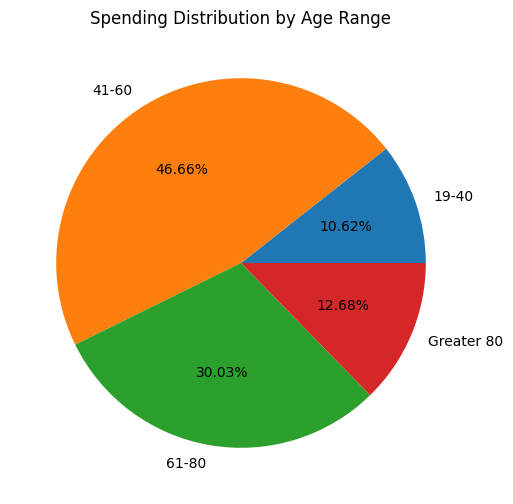

In [ ]:
# *** 6. Spending Distribution by Age Range


# Range 1: 0 -> 18 
# Range 2: 19 -> 40
# Range 3: 41 -> 60
# Range 4: 60 -> 80
# Range 5: > 81

def caculateAgeRange(birth_year):
    if datetime.now().year - birth_year <= 18:
        return 1
    elif datetime.now().year - birth_year <= 40:
        return 2
    elif datetime.now().year - birth_year <= 60:
        return 3
    elif datetime.now().year - birth_year <= 80:
        return 4
    else:
        return 5
    
ageRangeDict = {1:'Under 19', 2:'19-40', 3:'41-60', 4:'61-80', 5: 'Greater 80'}

# Dataframe containers user with birth year, age range
userAgeDf = userDf[['id', 'birth_year']]   
userAgeDf['age'] = userAgeDf['birth_year'].apply(lambda birthYear: datetime.now().year - birthYear)
userAgeDf['age_range'] = userAgeDf['birth_year'].apply(caculateAgeRange)

# Dataframe with sum of total spending user id (client_id)
userAgeSpendingDf = totalSpendingByClient.reset_index()

# Merge total spending dataframe with age range dataframe
userAgeSpendingDf = userAgeSpendingDf.merge(userAgeDf, left_on='client_id', right_on='id', how='left')
userAgeSpendingDf.head()

# sum by age range
userAgeRangeTotalSpedningDf = userAgeSpendingDf.groupby('age_range')['amount'].sum().reset_index()
print(type(userAgeRangeTotalSpedningDf))

# basing on the age range' value -> get the approriate label
userAgeRangeTotalSpedningDf['age_range'] = userAgeRangeTotalSpedningDf['age_range'].apply(lambda ageRange: ageRangeDict[ageRange] )
userAgeRangeTotalSpedningDf.head()

# Draw pie plot
plt.figure(figsize=(8,6))
plt.title('Spending Distribution by Age Range')
plt.pie(userAgeRangeTotalSpedningDf['amount'], labels=userAgeRangeTotalSpedningDf['age_range'], autopct='%1.2f%%')
plt.show()





In [ ]:
# 1gp. Customer Spending Distribution
spending_txn = transactionDf[transactionDf['amount'] < 0].copy()

spending_txn['spending_amount'] = spending_txn['amount'].abs()

customer_spending = (
    spending_txn
    .groupby('client_id')['spending_amount']
    .sum()
    .reset_index()
    .rename(columns={'spending_amount': 'total_spending'})
)

customer_spending['total_spending'].describe()

plt.figure(figsize=(10, 5))
sns.histplot(customer_spending['total_spending'], bins=50, kde=True)
plt.title("Distribution of Total Customer Spending")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()


plt.figure(figsize=(10, 3))
sns.boxplot(x=customer_spending['total_spending'])
plt.title("Customer Spending Boxplot")
plt.show()


# Top 10 spending customer
top_spenders = customer_spending.sort_values(
    by='total_spending', ascending=False
).head(10)

# Proposal

customer_spending['log_spending'] = np.log1p(customer_spending['total_spending'])

plt.figure(figsize=(10, 5))
sns.histplot(customer_spending['log_spending'], bins=50, kde=True)
plt.title("Log-Transformed Customer Spending Distribution")
plt.xlabel("Log(Total Spending)")
plt.ylabel("Number of Customers")
plt.show()




In [ ]:
# 2gp. Transaction Frequency of Customer

customer_txn_count = (
    transactionDf
    .groupby('client_id')
    .size()
    .reset_index(name='transaction_count')
)

customer_txn_count['transaction_count'].describe()

plt.figure(figsize=(10, 5))
sns.histplot(customer_txn_count['transaction_count'], bins=50, kde=True)
plt.title("Distribution of Transaction Frequency per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.show()


# Classify by activity frequency

def classify_activity(txn_count):
    if txn_count < 10:
        return "Low Activity"
    elif txn_count < 50:
        return "Medium Activity"
    else:
        return "High Activity"

customer_txn_count['activity_level'] = (
    customer_txn_count['transaction_count']
    .apply(classify_activity)
)

plt.figure(figsize=(7, 5))
sns.countplot(
    data=customer_txn_count,
    x='activity_level',
    order=['Low Activity', 'Medium Activity', 'High Activity']
)
plt.title("Customer Activity Level Distribution")
plt.xlabel("Activity Level")
plt.ylabel("Number of Customers")
plt.show()




In [ ]:
# 3gp. MCC Spending Behavior
mccCodeDf = pd.read_csv("mcc_codes.csv")

spending_txn = transactionDf[transactionDf['amount'] < 0].copy()
spending_txn['spending_amount'] = spending_txn['amount'].abs()

mcc_spending = (
    spending_txn
    .groupby('mcc')
    .agg(
        total_spending=('spending_amount', 'sum'),
        transaction_count=('spending_amount', 'count')
    )
    .reset_index()
)

mcc_spending = mcc_spending.merge(
    mccCodeDf,
    on='mcc',
    how='left'
)

top_mcc_spending = (
    mcc_spending
    .sort_values(by='total_spending', ascending=False)
    .head(10)
)

top_mcc_spending[['mcc', 'description', 'total_spending']]


plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_mcc_spending,
    y='description',
    x='total_spending'
)
plt.title("Top 10 MCC by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Merchant Category")
plt.show()


# Top 10 by total spending
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_mcc_spending,
    y='description',
    x='total_spending'
)
plt.title("Top 10 MCC by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Merchant Category")
plt.show()

# Top 10 MCC by frequency

top_mcc_frequency = (
    mcc_spending
    .sort_values(by='transaction_count', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_mcc_frequency,
    y='description',
    x='transaction_count'
)
plt.title("Top 10 MCC by Transaction Count")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")
plt.show()



In [ ]:
# 4gp.Online vs Offline

transactionDf['channel'] = transactionDf['use_chip'].apply(
    lambda x: 'Online' if x == 'Online' else 'Offline'
)

channel_distribution = (
    transactionDf['channel']
    .value_counts(normalize=True) * 100
)

plt.figure(figsize=(6, 6))
sns.countplot(data=transactionDf, x='channel')
plt.title("Online vs Offline Transaction Distribution")
plt.xlabel("Transaction Channel")
plt.ylabel("Number of Transactions")
plt.show()




In [ ]:
# 5gp. Relationship between income and spending

userDf = pd.read_csv("users_data.csv")

spending_txn = transactionDf[transactionDf['amount'] < 0].copy()
spending_txn['spending_amount'] = spending_txn['amount'].abs()

customer_spending = (
    spending_txn
    .groupby('client_id')['spending_amount']
    .sum()
    .reset_index(name='total_spending')
)


income_spending = customer_spending.merge(
    userDf[['id', 'yearly_income']],
    left_on='client_id',
    right_on='id',
    how='left'
)

income_spending = income_spending.drop(columns=['id'])

income_spending[['yearly_income', 'total_spending']].describe()


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=income_spending,
    x='yearly_income',
    y='total_spending',
    alpha=0.6
)
plt.title("Yearly Income vs Total Spending")
plt.xlabel("Yearly Income")
plt.ylabel("Total Spending")
plt.show()




In [ ]:
# Tránh chia cho 0
userDtiDf = userDf[userDf['yearly_income'] > 0]


# Tính DTI
userDtiDf['dti'] = userDtiDf['total_debt'] / userDtiDf['yearly_income']

userDtiDf[['id', 'dti']].head()


plt.figure(figsize=(8, 6))
plt.hist(userDtiDf['dti'], bins=30, edgecolor='black')
plt.title("Distribution of Debt-to-Income Ratio (DTI)")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Customers")
plt.show()